In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import your custom package
from cooltrack.data_loader import load_grid
from cooltrack.models import ThermalEvolutionModels
from cooltrack.integrator import CoolingIntegrator
from cooltrack.initial_conditions import InitialConditions
from cooltrack.smoothing import TrackSmoother
from cooltrack.constants import INDEPENDENT_DIMS, Bands

sns.set_theme(style="whitegrid", context="talk")

# Paths
GRID_FILE_PATH = "../../exoweave/outputs/master_grid_data.h5"
#GRID_FILE_PATH = "../data/HADES_grid/hades_processed_grid.parquet" 
AGE_DATA_PATH = "../data/age_data/"

In [2]:
print("Using cooltrack.data_loader to fetch data...")
df_raw = load_grid(GRID_FILE_PATH)

# Let's use a smaller slice of the data so training is instant for our plot test
df_test_raw = df_raw[df_raw['mass_Mj'] <= 15].copy()
print(f"Loaded {len(df_test_raw):,} rows.")

2026-03-06 12:05:43,773 - INFO - Loading Exoweave HDF5 file: ../../exoweave/outputs/master_grid_data.h5...


Using cooltrack.data_loader to fetch data...


2026-03-06 12:05:52,590 - INFO - ✅ Exoweave Grid loaded and mapped successfully. Final shape: (1030, 43)


Loaded 773 rows.


In [3]:
print("Training models and removing numerical noise...")
ml_engine = ThermalEvolutionModels()

# Catch the cleaned dataframe!
df_clean = ml_engine.train_models(df_test_raw, tune_hyperparameters=False, clean_outliers=True)

print(f"Models trained! Retained {len(df_clean):,} clean physics points.")

2026-03-06 12:05:52,630 - INFO - Performing first-pass training to identify grid outliers...


Training models and removing numerical noise...


2026-03-06 12:05:56,431 - INFO - No massive outliers found in the grid.
2026-03-06 12:05:56,433 - INFO - Training T_int and Radius state models...
2026-03-06 12:06:16,129 - INFO - Training 15 photometric band models (this will take a minute)...
2026-03-06 12:07:36,161 - INFO - All photometry models trained successfully!
2026-03-06 12:07:36,179 - INFO - Training final baseline dS/dt model...
2026-03-06 12:07:50,401 - INFO - Final dS/dt test R^2: 0.9816


Models trained! Retained 773 clean physics points.


2026-03-06 12:07:50,545 - INFO - Loaded initial condition interpolators from 4 files.


Integrating a track for a 1.0 M_J, 3x Solar Met, 10 M_E Core Jupiter at 150 K...
Simulating Exact Planet:
 - Mass: 1.00 M_J
 - T_irr: 150 K
 - Metallicity: 0.47712125471966244x Solar
 - Core Mass: 10.0 (Assuming Earth Masses)
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


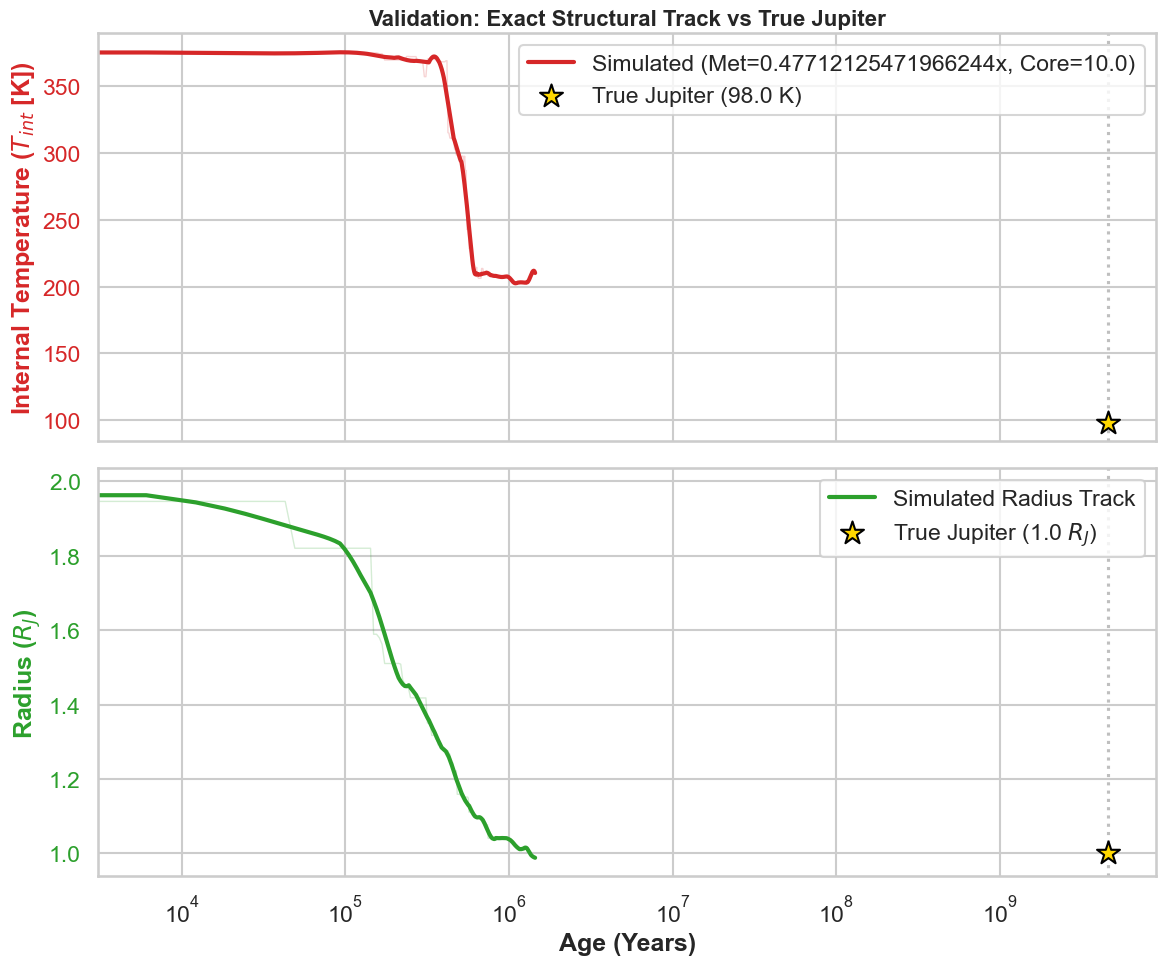

In [4]:
print("Integrating a track for a 1.0 M_J, 3x Solar Met, 10 M_E Core Jupiter at 150 K...")

init_cond = InitialConditions(AGE_DATA_PATH)
integrator = CoolingIntegrator(ml_engine)

# --- True Jupiter Values ---
JUPITER_AGE_YR = 4.56e9   
JUPITER_T_INT_K = 98.0    
JUPITER_RADIUS_RJ = 1.0   
SAFE_T_IRR_K = 150.0      
JUPITER_METALLICITY = np.log10(3) # 3x Solar
JUPITER_CORE_MASS = 10.0  # 10 Earth masses (adjust if your grid uses fractions!)

# --- Construct the EXACT Planet ---
# Find a baseline planet near our target so the inherited params (like kzz) make sense
baseline_mask = (np.isclose(df_clean['mass_Mj'], 1.0, atol=0.2)) & \
                (df_clean['T_irr'] >= SAFE_T_IRR_K)

baseline_candidates = df_clean[baseline_mask].sort_values('T_irr')

if baseline_candidates.empty:
    print("Could not find a valid baseline planet! Using fallback...")
    planet_row = df_clean.iloc[0].copy() 
else:
    planet_row = baseline_candidates.iloc[0].copy()
    
# OVERRIDE with the EXACT structural parameters we want to simulate!
planet_row['mass_Mj'] = 1.0
planet_row['T_irr'] = SAFE_T_IRR_K
planet_row['Met'] = JUPITER_METALLICITY
planet_row['core'] = JUPITER_CORE_MASS

print(f"Simulating Exact Planet:")
print(f" - Mass: {planet_row['mass_Mj']:.2f} M_J")
print(f" - T_irr: {planet_row['T_irr']:.0f} K")
print(f" - Metallicity: {planet_row['Met']}x Solar")
print(f" - Core Mass: {planet_row['core']} (Assuming Earth Masses)")

# --- Get Initial Conditions ---
s_hot_start = init_cond.get_starting_physical_entropy(planet_row['mass_Mj'], bin_index=19, n_bins=20)
s_cold_end = df_clean['S_physical'].min()

# --- Integrate the Cooling Track ---
ages, entropies = integrator.calculate_track(planet_row, s_hot_start, s_cold_end, num_points=250)

if ages is not None:
    fixed_params = planet_row[INDEPENDENT_DIMS].values.astype(float)
    t_ints_raw = []
    radii_raw = []
    
    for s in entropies:
        inp = np.append(fixed_params, s).reshape(1, -1)
        t_ints_raw.append(ml_engine.tint_model.predict(inp)[0])
        radii_raw.append(ml_engine.radius_model.predict(inp)[0])

    # --- Smooth the Tracks ---
    ages_arr = np.array(ages)
    t_ints_arr = np.array(t_ints_raw)
    radii_arr = np.array(radii_raw)
    
    t_ints_smooth = TrackSmoother.smooth(ages_arr, t_ints_arr, method='savgol', window_length=31, polyorder=3)
    radii_smooth = TrackSmoother.smooth(ages_arr, radii_arr, method='savgol', window_length=31, polyorder=3)
    ages_smooth = TrackSmoother.smooth(ages_arr, ages_arr, method='savgol', window_length=31)

    # --- Plotting (2 Panels) ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Panel 1: Internal Temperature
    color1 = 'tab:red'
    ax1.plot(ages_arr, t_ints_arr, color=color1, lw=1, alpha=0.2)
    ax1.plot(ages_smooth, t_ints_smooth, color=color1, lw=3, label=f"Simulated (Met={JUPITER_METALLICITY}x, Core={JUPITER_CORE_MASS})")
    ax1.scatter([JUPITER_AGE_YR], [JUPITER_T_INT_K], color='gold', edgecolor='black', 
                s=300, marker='*', zorder=5, label=f"True Jupiter ({JUPITER_T_INT_K} K)")
    
    ax1.set_ylabel('Internal Temperature ($T_{int}$ [K])', color=color1, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.axvline(JUPITER_AGE_YR, color='gray', linestyle=':', alpha=0.5, zorder=0)
    ax1.legend(loc="upper right")
    ax1.set_title(f"Validation: Exact Structural Track vs True Jupiter", fontsize=16, fontweight='bold')

    # Panel 2: Radius Evolution
    color2 = 'tab:green'
    ax2.plot(ages_arr, radii_arr, color=color2, lw=1, alpha=0.2)
    ax2.plot(ages_smooth, radii_smooth, color=color2, lw=3, label="Simulated Radius Track")
    ax2.scatter([JUPITER_AGE_YR], [JUPITER_RADIUS_RJ], color='gold', edgecolor='black', 
                s=300, marker='*', zorder=5, label=f"True Jupiter (1.0 $R_J$)")
    
    ax2.set_ylabel('Radius ($R_J$)', color=color2, fontweight='bold')
    ax2.set_xlabel('Age (Years)', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_xscale('log')
    ax2.axvline(JUPITER_AGE_YR, color='gray', linestyle=':', alpha=0.5, zorder=0)
    ax2.legend(loc="upper right")
    
    fig.tight_layout()
    plt.show()
else:
    print("Integration failed.")

2026-03-06 12:07:57,151 - INFO - Loaded initial condition interpolators from 4 files.


Integrating a track for a 1.0 M_J Jupiter analog...
Bands.find(): Guessed 'MIRI_F1000W' from input 'miri 1000'
Band 1 mapped to: MIRI_F1000W_Flambda_wm2um
Band 2 mapped to: NIRISS_F277W_Flambda_wm2um


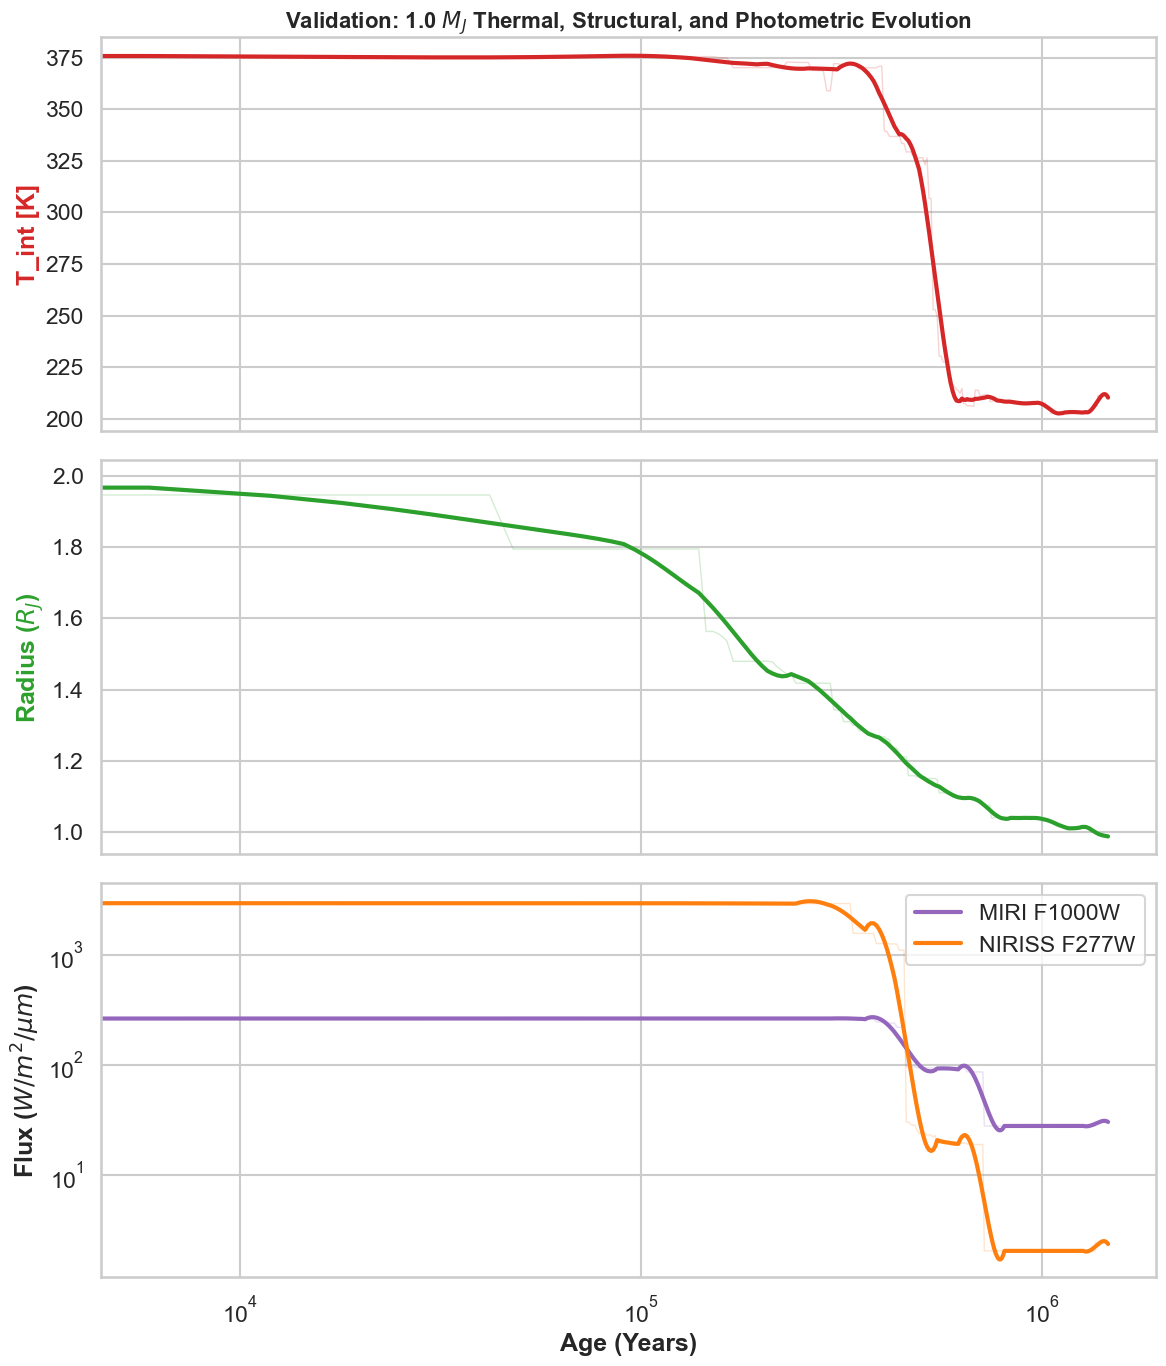

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from cooltrack.smoothing import TrackSmoother
from cooltrack.initial_conditions import InitialConditions
from cooltrack.constants import INDEPENDENT_DIMS

print("Integrating a track for a 1.0 M_J Jupiter analog...")

init_cond = InitialConditions(AGE_DATA_PATH)
integrator = CoolingIntegrator(ml_engine)

SAFE_T_IRR_K = 150.0      
JUPITER_METALLICITY = 0.0
JUPITER_CORE_MASS = 10.0  

baseline_mask = (np.isclose(df_clean['mass_Mj'], 1.0, atol=0.2)) & (df_clean['T_irr'] >= SAFE_T_IRR_K)
baseline_candidates = df_clean[baseline_mask].sort_values('T_irr')

planet_row = baseline_candidates.iloc[0].copy() if not baseline_candidates.empty else df_clean.iloc[0].copy()
planet_row['mass_Mj'] = 1.0
planet_row['T_irr'] = SAFE_T_IRR_K
planet_row['Met'] = JUPITER_METALLICITY
planet_row['core'] = JUPITER_CORE_MASS

s_hot_start = init_cond.get_starting_physical_entropy(planet_row['mass_Mj'], bin_index=19, n_bins=20)
s_cold_end = df_clean['S_physical'].min()

ages, entropies = integrator.calculate_track(planet_row, s_hot_start, s_cold_end, num_points=250)

if ages is not None:
    fixed_params = planet_row[INDEPENDENT_DIMS].values.astype(float)
    t_ints_raw, radii_raw = [], []
    
    # We will pick two specific bands to plot
    # You can type it completely casually:
    band_1 = Bands.find('miri 1000')
    band_2 = Bands.find('f277')

    print(f"Band 1 mapped to: {band_1}")
    print(f"Band 2 mapped to: {band_2}")

    flux_1_raw, flux_2_raw = [], []
    
    for s in entropies:
        inp = np.append(fixed_params, s).reshape(1, -1)
        t_ints_raw.append(ml_engine.tint_model.predict(inp)[0])
        radii_raw.append(ml_engine.radius_model.predict(inp)[0])
        
        # Predict the log10 of the fluxes, then convert back to actual flux!
        log_f1 = ml_engine.photo_models[band_1].predict(inp)[0]
        log_f2 = ml_engine.photo_models[band_2].predict(inp)[0]
        flux_1_raw.append(10**log_f1)
        flux_2_raw.append(10**log_f2)

    # --- Smooth the Tracks ---
    ages_arr = np.array(ages)
    t_ints_arr, radii_arr = np.array(t_ints_raw), np.array(radii_raw)
    flux_1_arr, flux_2_arr = np.array(flux_1_raw), np.array(flux_2_raw)
    
    # We smooth the Log fluxes to avoid math weirdness
    log_flux1_smooth = TrackSmoother.smooth(ages_arr, np.log10(flux_1_arr), method='savgol', window_length=31)
    log_flux2_smooth = TrackSmoother.smooth(ages_arr, np.log10(flux_2_arr), method='savgol', window_length=31)
    
    t_ints_smooth = TrackSmoother.smooth(ages_arr, t_ints_arr, method='savgol', window_length=31, polyorder=3)
    radii_smooth = TrackSmoother.smooth(ages_arr, radii_arr, method='savgol', window_length=31, polyorder=3)
    ages_smooth = TrackSmoother.smooth(ages_arr, ages_arr, method='savgol', window_length=31)

    # --- Plotting (3 Panels) ---
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
    
    # Panel 1: T_int
    ax1.plot(ages_arr, t_ints_arr, color='tab:red', lw=1, alpha=0.2)
    ax1.plot(ages_smooth, t_ints_smooth, color='tab:red', lw=3)
    ax1.set_ylabel('T_int [K]', color='tab:red', fontweight='bold')
    ax1.set_title(f"Validation: 1.0 $M_J$ Thermal, Structural, and Photometric Evolution", fontsize=16, fontweight='bold')

    # Panel 2: Radius
    ax2.plot(ages_arr, radii_arr, color='tab:green', lw=1, alpha=0.2)
    ax2.plot(ages_smooth, radii_smooth, color='tab:green', lw=3)
    ax2.set_ylabel('Radius ($R_J$)', color='tab:green', fontweight='bold')

    # Panel 3: Photometry
    ax3.plot(ages_arr, flux_1_arr, color='tab:purple', lw=1, alpha=0.2)
    ax3.plot(ages_smooth, 10**log_flux1_smooth, color='tab:purple', lw=3, label="MIRI F1000W")
    
    ax3.plot(ages_arr, flux_2_arr, color='tab:orange', lw=1, alpha=0.2)
    ax3.plot(ages_smooth, 10**log_flux2_smooth, color='tab:orange', lw=3, label="NIRISS F277W")
    
    ax3.set_ylabel('Flux ($W/m^2/\mu m$)', fontweight='bold')
    ax3.set_xlabel('Age (Years)', fontweight='bold')
    ax3.set_yscale('log') # Flux spans orders of magnitude!
    ax3.set_xscale('log')
    ax3.legend(loc="upper right")
    
    fig.tight_layout()
    plt.show()
else:
    print("Integration failed.")